# 🤖 __Class 4: Introduction to Machine Learning (ML) en BI__ 📊
---

## 🛠️ __1. Setting up the environment:__ Main imports 📚
---

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from statsmodels.graphics.gofplots import qqplot

In [23]:
x = np.linspace(0,1,10)

In [2]:
housing_data = fetch_california_housing()
df = pd.DataFrame(housing_data.data, columns=housing_data.feature_names)
df['MedHouseVal'] = housing_data.target   
df.head() 

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 📝 __2. Data Schema Definition:__ Variable Exploration 🗂️
---

| ID | Nombre del Campo | Descripción y Uso en BI | Rango Esperado | Tipos de Variables | Ejemplo Práctico |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **0** | <font color="#7abaff">**MedInc**</font> | Ingreso medio de los hogares en el bloque. | $[0.5, 15.0]$ | Cuantitativa Continua | 8.32 $\approx$ $83,200 |
| **1** | <font color="#7abaff">**HouseAge**</font> | Antigüedad media de las viviendas. | $[1, 52]$ | Cuantitativa Discreta | 41.0 años |
| **2** | <font color="#7abaff">**AveRooms**</font> | Promedio de habitaciones por hogar. | $[0.8, 140]$ | Cuantitativa Continua | 6.98 habitaciones |
| **3** | <font color="#7abaff">**AveBedrms**</font> | Promedio de dormitorios por hogar. | $[0.3, 34]$ | Cuantitativa Continua | 1.02 dormitorios |
| **4** | <font color="#7abaff">**Population**</font> | Población total residente en el bloque. | $[3, 35000]$ | Cuantitativa Discreta | 322.0 habitantes |
| **5** | <font color="#7abaff">**AveOccup**</font> | Promedio de personas por hogar. | $[0.6, 1200]$ | Cuantitativa Continua | 2.55 personas |
| **6** | <font color="#ffd43b">**Latitude**</font> | Ubicación geográfica (Eje Norte-Sur). | $[32.5, 41.9]$ | Cuantitativa Continua | 37.88° |
| **7** | <font color="#ffd43b">**Longitude**</font> | Ubicación geográfica (Eje Este-Oeste). | $[-124, -114]$ | Cuantitativa Continua | -122.23° |
| **8** | <font color="#ff6b6b">**MedHouseVal**</font> | **Variable Objetivo:** Valor medio de la casa. | $[0.15, 5.0]$ | Cuantitativa Continua | 4.52 $\approx$ $452,000 |

## 🗺️ __Let's explore out data__ 🔍
---

C:\Users\USER\AppData\Local\Temp\ipykernel_21628\1538346426.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df,


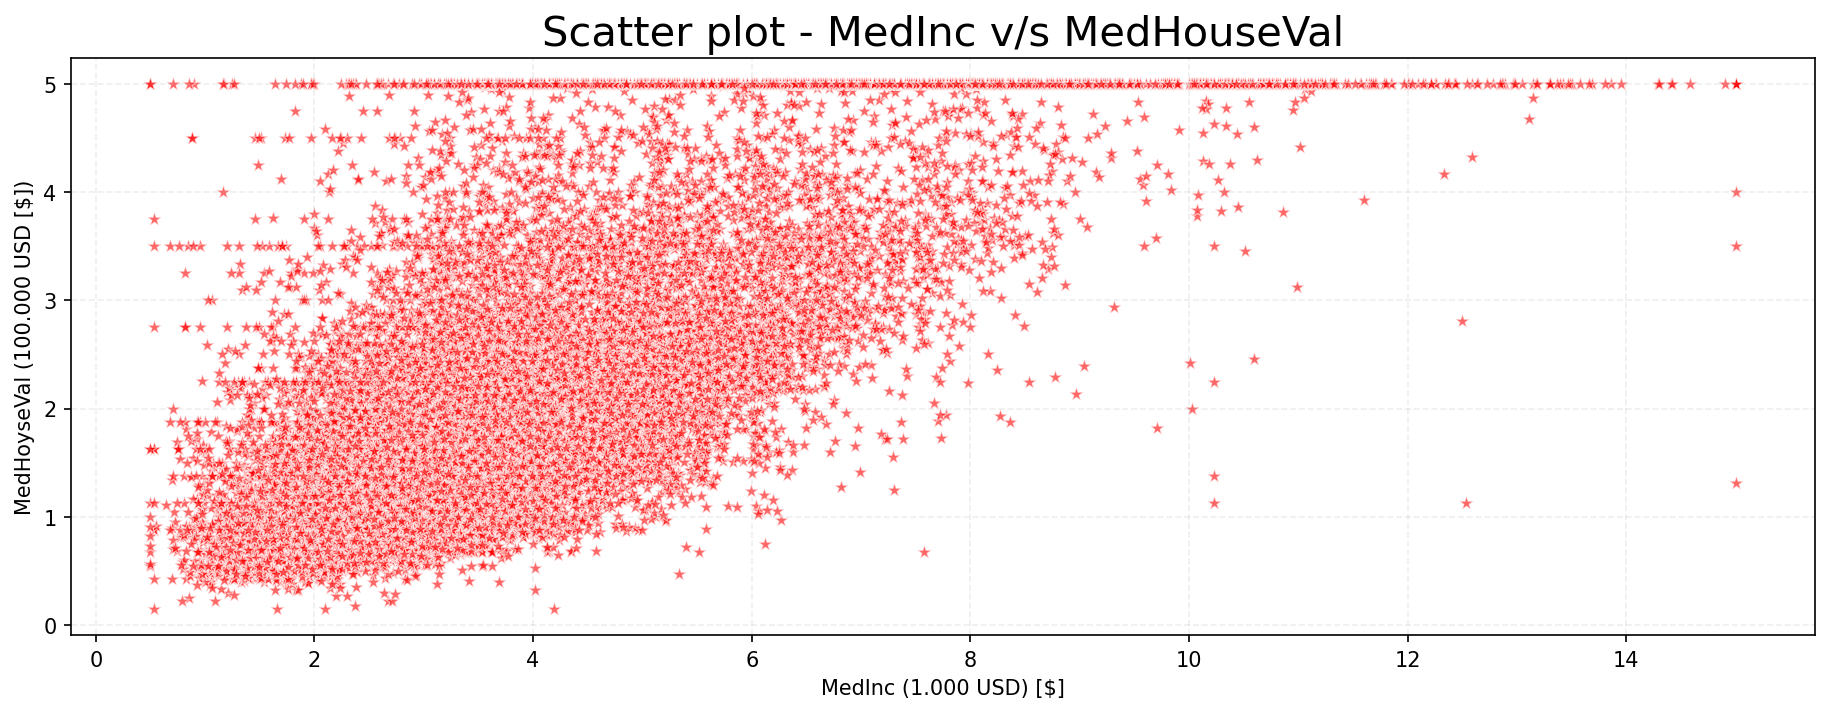

In [3]:
# BOXPLOT MedInc - MedHouseVal

plt.figure(figsize=(15, 5), dpi = 150)

sns.scatterplot(data=df, 
                x = 'MedInc',
                y='MedHouseVal',
                alpha=0.6, 
                palette = 'bright',
                color = 'red',
                marker = '*',
                s = 50)

plt.title('Scatter plot - MedInc v/s MedHouseVal', fontsize = 20)
plt.xlabel('MedInc (1.000 USD) [$]')
plt.ylabel('MedHoyseVal (100.000 USD [$])')
plt.grid(True, linestyle='--', alpha=0.2)
plt.savefig("Scatter_plot_MedInc_MedHouseVal")
plt.show()

In [4]:
#info() Method
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
#describe() method
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


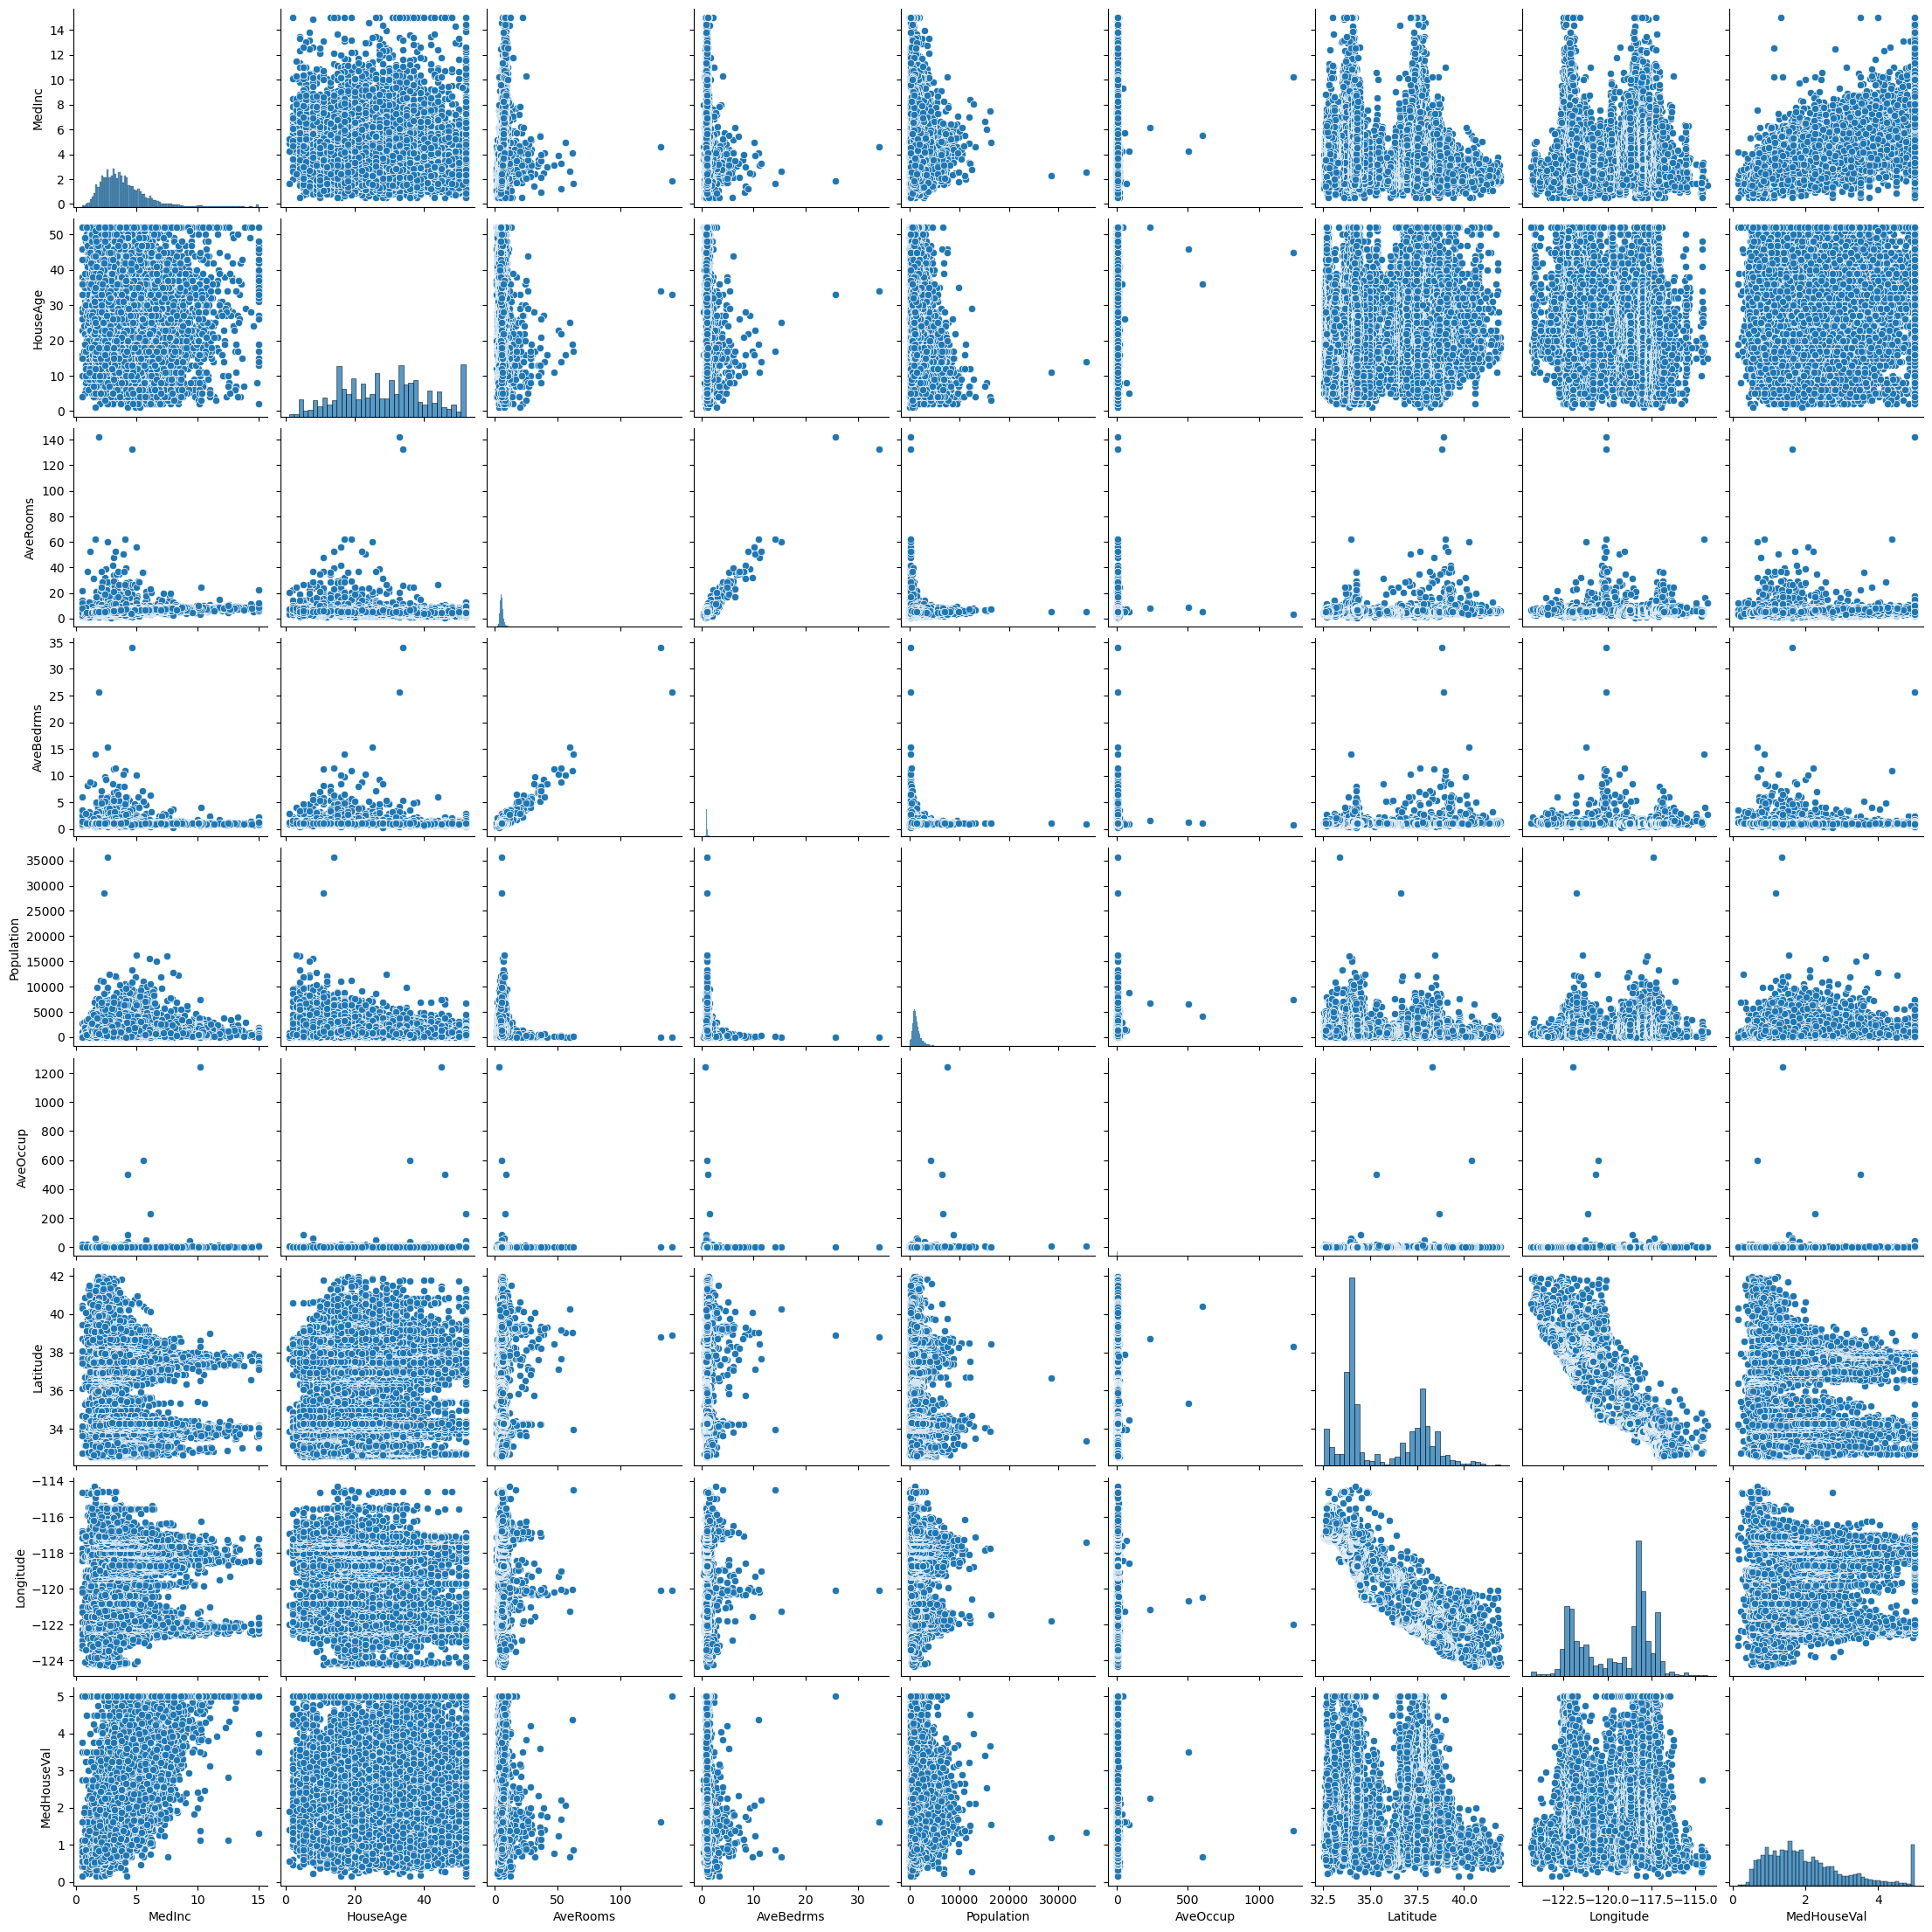

In [6]:
#pairplot
sns.pairplot(df)
plt.show()

In [7]:
#Correlation Matrix + Heatmap
corr_matrix = df.corr(method = 'pearson')
corr_matrix

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


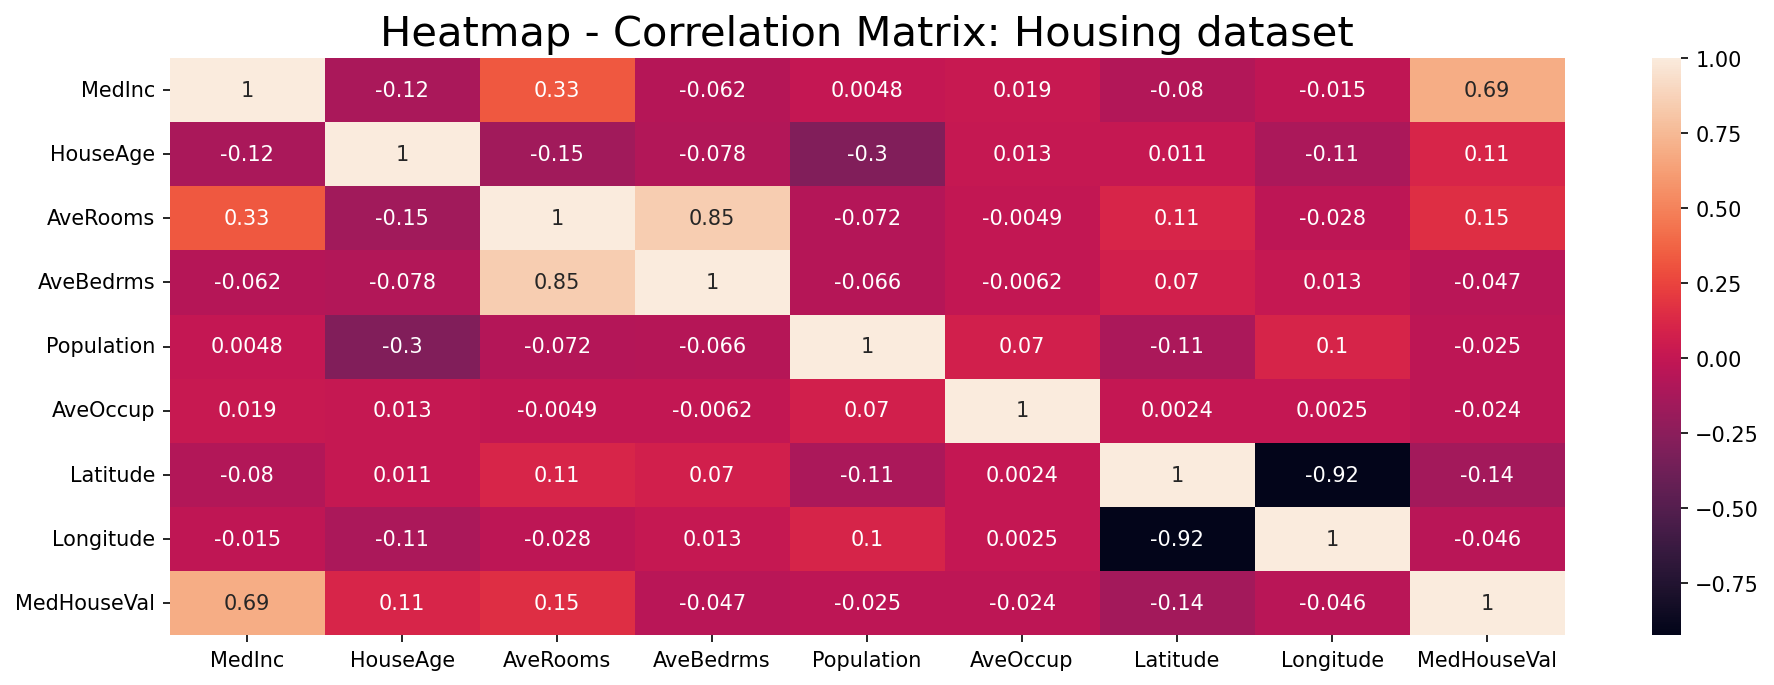

In [8]:
plt.figure(figsize = (15,5), dpi = 150)
sns.heatmap( data = corr_matrix, annot = True)
plt.title("Heatmap - Correlation Matrix: Housing dataset", fontsize = 20)
plt.savefig("Heatmap - Correlation Matrix: Housing dataset.png", dpi = 150)
plt.show()

## 📈 __OLS Simple Linear Regression:__ <code>Statsmodels</code> 📊
---

In [9]:
# PREVIEW THE DATA TO VERIFY TARGET AND PREDICTORS
df[['MedInc', 'MedHouseVal']].head()

,MedInc,MedHouseVal
0,8.3252,4.526
1,8.3014,3.585
2,7.2574,3.521
3,5.6431,3.413
4,3.8462,3.422


In [10]:
# SPLIT DATA INTO TRAIN AND TEST SETS TO PROTECT GENERALIZATION
train, test = train_test_split(df, test_size=0.2, random_state=42)

In [11]:
#LET'S CHECK OUR TRAINING AND TESTING DATASET

In [12]:
# DEFINE LINEAR RELATIONSHIP USING FORMULA SYNTAX
# THE INTERCEPT IS AUTOMATICALLY INCLUDED BY DEFAULT
formula = 'MedHouseVal ~ MedInc'
model = smf.ols(formula=formula, data = train).fit()

# DISPLAY DETAILED REGRESSION STATISTICS
# CHECK INTERCEPT AND COEFFICIENT SIGNIFICANCE
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.477
Model:                            OLS   Adj. R-squared:                  0.477
Method:                 Least Squares   F-statistic:                 1.506e+04
Date:                Wed, 17 Jun 2026   Prob (F-statistic):               0.00
Time:                        13:05:25   Log-Likelihood:                -20475.
No. Observations:               16512   AIC:                         4.095e+04
Df Residuals:                   16510   BIC:                         4.097e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.4446      0.015     30.096      0.0

## 🚀 __Performance Assessment__ 📊
---

In [13]:
# GENERATE PREDICTIONS FOR PERFORMANCE ASSESSMENT
y_train_pred = model.predict(train)
y_test_pred = model.predict(test)

# COMPUTE KEY PERFORMANCE INDICATORS FOR BOTH SETS
metrics = {
    'MAE': [mean_absolute_error(train['MedHouseVal'], y_train_pred), 
            mean_absolute_error(test['MedHouseVal'], y_test_pred)],
    'RMSE': [np.sqrt(mean_squared_error(train['MedHouseVal'], y_train_pred)), 
             np.sqrt(mean_squared_error(test['MedHouseVal'], y_test_pred))],
    'MAPE(%)': [100*mean_absolute_percentage_error(train['MedHouseVal'], y_train_pred), 
             100*mean_absolute_percentage_error(test['MedHouseVal'], y_test_pred)]
}

# OUTPUT PERFORMANCE TABLE FOR COMPARISON
performance_df = pd.DataFrame(metrics, index=['Train', 'Test'])
print("\n - MODEL PERFORMANCE BENCHMARKS")

performance_df.round(4)


 - MODEL PERFORMANCE BENCHMARKS


,MAE,RMSE,MAPE(%)
Train,0.6250,0.8361,38.4723
Test,0.6299,0.8421,39.0558


## 🔮 __Let's make predictions__ 🎯
---

In [14]:
# SELECT A RANDOM SAMPLE FROM THE TEST SET TO COMPARE
# THIS SHOWS STUDENTS HOW CLOSE THE MODEL IS TO REALITY
validation_sample = test[['MedInc', 'MedHouseVal']].sample(5, random_state=42)
validation_sample['Predicted_Price'] = model.predict(validation_sample)

# CALCULATE THE ERROR FOR EACH SAMPLE ROW
validation_sample['Error'] = validation_sample['MedHouseVal'] - validation_sample['Predicted_Price']

print("VALIDATION: EXISTING RECORDS VS PREDICTIONS")
print(validation_sample.round(4))

VALIDATION: EXISTING RECORDS VS PREDICTIONS
       MedInc  MedHouseVal  Predicted_Price   Error
3752   2.8208        2.385           1.6275  0.7575
16705  4.3611        3.297           2.2734  1.0236
2915   4.3482        0.952           2.2680 -1.3160
9728   4.5787        2.451           2.3646  0.0864
3352   2.5000        0.641           1.4929 -0.8519


In [15]:
# TESTING THE MODEL WITH HYPOTHETICAL INCOME LEVELS
# ADDING AN EXTREME CASE (20.0) TO CHECK MODEL BEHAVIOR
new_scenarios = pd.DataFrame({'MedInc': [2.5, 5.0, 8.5, 12.0, 20.0]})

# GENERATE PREDICTIONS FOR THESE NEW SCENARIOS
new_predictions = model.predict(new_scenarios)

# COMBINE INPUTS AND OUTPUTS FOR PRESENTATION
inference_table = new_scenarios.copy()
inference_table['Predicted_Price'] = new_predictions

print("\nNEW SCENARIO INFERENCE (INCLUDING EXTREME CASE)")
print(inference_table.round(4))


NEW SCENARIO INFERENCE (INCLUDING EXTREME CASE)
   MedInc  Predicted_Price
0     2.5           1.4929
1     5.0           2.5413
2     8.5           4.0090
3    12.0           5.4767
4    20.0           8.8314


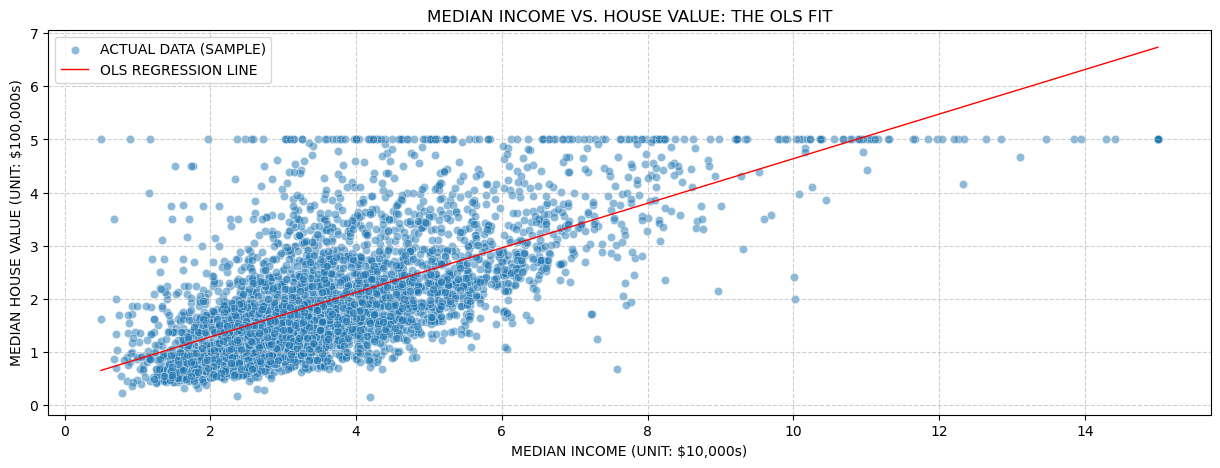

In [16]:
# SAMPLE THE DATA FOR BETTER VISUAL CLARITY
# PLOTTING 20,000+ POINTS CAN BE MESSY
plot_sample = test.sample(4000, random_state=42)

# GENERATE THE LINE COORDINATES USING THE MODEL'S PARAMETERS
x_line = np.linspace(plot_sample['MedInc'].min(), plot_sample['MedInc'].max(), 100)
y_line = model.params['Intercept'] + model.params['MedInc'] * x_line

# CREATE THE FINAL PLOT
plt.figure(figsize=(15, 5))
 
# PLOT ACTUAL DATA POINTS
sns.scatterplot(data=plot_sample, x='MedInc', y='MedHouseVal', alpha=0.5, label='ACTUAL DATA (SAMPLE)')

# PLOT THE OLS REGRESSION LINE
plt.plot(x_line, y_line, color='red', linewidth=1, label='OLS REGRESSION LINE')

# FORMATTING THE CHART FOR PRESENTATION
plt.title('MEDIAN INCOME VS. HOUSE VALUE: THE OLS FIT')
plt.xlabel('MEDIAN INCOME (UNIT: $10,000s)')
plt.ylabel('MEDIAN HOUSE VALUE (UNIT: $100,000s)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

## 📚 __Residual sanity check__ 🚨
---

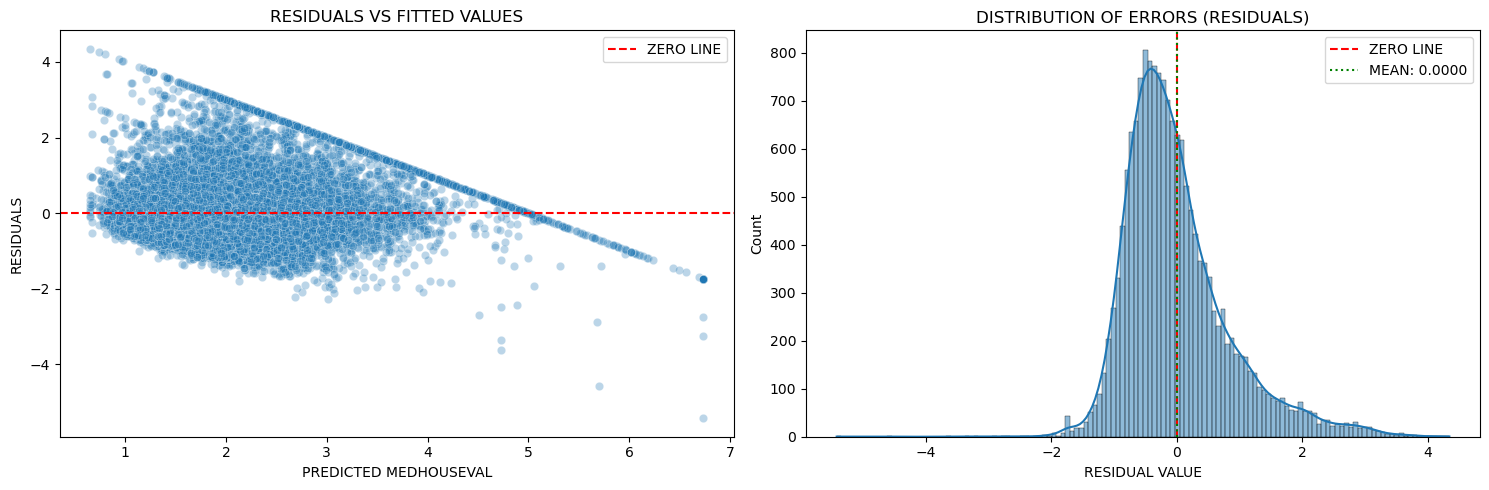

In [17]:
# PREPARE RESIDUALS AND FITTED VALUES FOR DIAGNOSTICS
residuals = model.resid
fitted = model.fittedvalues
res_mean = np.mean(residuals)

# VISUAL INSPECTION OF ERROR DISTRIBUTION AND INDEPENDENCE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# CHECK FOR CONSTANT VARIANCE AND INDEPENDENCE
sns.scatterplot(x=fitted, y=residuals, alpha=0.3, ax=ax1)
ax1.axhline(0, color='red', linestyle='--', label='ZERO LINE')
ax1.set_title('RESIDUALS VS FITTED VALUES')
ax1.set_xlabel('PREDICTED MEDHOUSEVAL')
ax1.set_ylabel('RESIDUALS')
ax1.legend()

# CHECK FOR ERROR DISTRIBUTION AND MEAN ALIGNMENT
sns.histplot(residuals, kde=True, ax=ax2)
ax2.axvline(0, color='red', linestyle='--', label='ZERO LINE')
ax2.axvline(res_mean, color='green', linestyle=':', label=f'MEAN: {res_mean:.4f}')
ax2.set_title('DISTRIBUTION OF ERRORS (RESIDUALS)')
ax2.set_xlabel('RESIDUAL VALUE')
ax2.legend()

plt.tight_layout()
plt.show()